<a href="https://colab.research.google.com/github/Amady01/NoteBook_GCI-2026/blob/main/OHsession_LogisticRegforAdRetention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression for Advertisement Regression**
by: Warutchot Rattanaphupha



# Logistic Regression Algorithm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class LogisticRegresion:
    def __init__(self):
        self.X = 0
        self.y = 0
        self.m = 0
        self.z = 0
        self.theta = 0
        self.all = 0
        self.cost_history = 0

    def gendata(self, num,
            c0_x1=1, c0_x2=5,    # center class 0
            c1_x1=3, c1_x2=2,    # center class 1
            std=1.0):

        self.all = num
        x1_0 = np.random.randn(num) * std + c0_x1
        x2_0 = np.random.randn(num) * std + c0_x2
        y_0  = np.zeros(num)

        x1_1 = np.random.randn(num) * std + c1_x1
        x2_1 = np.random.randn(num) * std + c1_x2
        y_1  = np.ones(num)

        X1 = np.concatenate((x1_0, x1_1))
        X2 = np.concatenate((x2_0, x2_1))

        self.X = np.stack((X1, X2), axis=1)

        self.y = np.concatenate((y_0, y_1)).reshape(-1, 1)

        print("X shape:", self.X.shape)
        print("y shape:", self.y.shape)
        self.m = len(self.y)
        ones = np.ones((self.m, 1))
        self.X_b = np.concatenate((ones, self.X), axis=1)
        # z=w0​+w1​x1​+w2​x2​
        print("Original X shape:", self.X.shape)
        print("X with Bias shape:", self.X_b.shape)

        return self.X , self.X_b ,self.y ,self.m, self.all

    # Sigmoid Function
    # 80%/ 100%-80% = 80/20
    # odd = p / 1-p
    # take ln  z = np.log(odd)
    # odd_back = np.exp(z)
    # p_back = odd_back / (1 + odd_back)
    # sigmoid = 1 / (1 + np.exp(-z))
    def sigmoid(self,z):
        return 1 / (1 + np.exp(-z))

    # Logloss or Cross-Entropy Loss
    # log(L) = sum( y*log(p) + (1-y)*log(1-p) )
    # step1 = np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    # step2 = np.sum(y * np.log(h) + np.log(1 - h) - y * np.log(1 - h))
    # step3 = np.sum(np.log(1 - h) + y * np.log(h / (1 - h)))
    # step4 = np.sum(-np.log(1 + np.exp(z)) + y * z)
    def Logloss(self):
        log_likelihood = np.sum(-np.log(1 + np.exp(self.z)) + self.y * self.z)
        return -(1/self.m) * log_likelihood

    def normalize(self):
      self.X_mean = self.X.mean(axis=0)
      self.X_std  = self.X.std(axis=0)
      X_norm = (self.X - self.X_mean) / self.X_std
      ones = np.ones((self.m, 1))
      self.X_b = np.concatenate((ones, X_norm), axis=1)

    #  Gradient Descent find the best parameter (w and b) for make it occurs Maximum Likelihood (In ml we need lowest so we -)
    # theta = Weights
    def fit(self,epochs, lr=0.01):
        self.cost_history = []
        n_features = self.X_b.shape[1]
        self.theta = np.zeros((n_features, 1))

        for i in range(epochs):
            # 1.Linear z = (w1 *x1) + (w2*x2) + b
            self.z = np.matmul(self.X_b, self.theta)
            # 2.Convert to prob
            h = self.sigmoid(self.z)

            # 3.Gradient
            # we diff Log loss to find rate of change if we change w and b
            # First Loss = - [ - \ln(1 + e^z) + yz ]
            # we diff - ( - \ln(1 + e^z) ) we wil got SIGMOID or h
            # we diff -yz by z we got -y
            # result = h-y
            # now we know  diff  Loss/z = h - y (if we change  z then Loss(h-y) what will gonna be)
            # next step is find rate of change weigth  z = w*x + b we will dif w*x by w we got x
            # result is Loss/rate of change W = h-y * x Now we know already !! we got Gradient
            gradient = (1/self.m) * np.matmul(self.X_b.T, h - self.y)

            # 4. Updated Theta
            self.theta = self.theta - (lr * gradient)

            # Negative Log likelihood: -(y*log(h) + (1-y)*log(1-h))
            cost = self.Logloss()
            self.cost_history.append(cost)

            if i % 100 == 0:
                 print(f"Epoch {i}: Cost = {cost:.4f}")

        # print("Final Theta:", self.theta.flatten())
        return self.cost_history

    def predict(self, X_new):
      X_new_norm = (X_new - self.X_mean) / self.X_std
      m_new = X_new_norm.shape[0]
      ones = np.ones((m_new, 1))
      X_new_b = np.concatenate((ones, X_new_norm), axis=1)

      z_new = np.matmul(X_new_b, self.theta)

      probability = self.sigmoid(z_new)
      predictions = (probability >= 0.5).astype(int)

      return predictions, probability

    def plot_result(self):
        plt.figure(figsize=(8, 6))

        plt.scatter(self.X[:self.all, 0], self.X[:self.all, 1], color='purple', label='Class 0')
        plt.scatter(self.X[self.all:, 0], self.X[self.all:, 1], color='yellow', label='Class 1')
        x_values = np.array([np.min(self.X[:,0]), np.max(self.X[:,0])])
        y_values = - (self.theta[0] + self.theta[1] * x_values) / self.theta[2]

        plt.plot(x_values, y_values, label='Decision Boundary', color='red', linewidth=2)

        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.title('Logistic Regression from Scratch')
        plt.show()

    def plot_cost(self):
        plt.figure(figsize=(8,5))
        plt.plot(self.cost_history)
        plt.xlabel("Epoch")
        plt.ylabel("Cost")
        plt.title("Cost Over Time")
        plt.show()

    def load_csv(self, filepath):
        df = pd.read_csv(filepath)

        # Drop non-numeric / text columns
        drop = ['Ad Topic Line', 'City', 'Country', 'Timestamp']
        df = df.drop(columns=[c for c in drop if c in df.columns])

        # split feature
        target_col = 'Clicked on Ad'
        X_df = df.drop(columns=[target_col])
        y_df = df[target_col]

        self.X = X_df.values.astype(float)
        self.y = y_df.values.reshape(-1, 1).astype(float)
        self.m = len(self.y)
        self.all = self.m

        # add bias column
        ones = np.ones((self.m, 1))
        self.X_b = np.concatenate((ones, self.X), axis=1)

        print("Columns used:", list(X_df.columns))
        print("X shape:", self.X.shape)
        print("y shape:", self.y.shape)

        return self.X, self.X_b, self.y, self.m


    def plotresult_csv(self):
      plt.figure(figsize=(8, 6))

      f1, f2 = 0, 3
      feature_names = ['Daily Time Spent', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']

      clicked     = self.X[self.y.flatten() == 1]
      not_clicked = self.X[self.y.flatten() == 0]

      plt.scatter(not_clicked[:, f1], not_clicked[:, f2], color='purple', alpha=0.5, label='Not Clicked')
      plt.scatter(clicked[:, f1],     clicked[:, f2],     color='yellow', edgecolors='gray', alpha=0.5, label='Clicked')


      x_values = np.linspace(self.X[:, f1].min(), self.X[:, f1].max(), 100)
      x_norm   = (x_values - self.X_mean[f1]) / self.X_std[f1]

      # w0 + w1*x1_norm + w2*x2_norm = 0  →  x2_norm = -(w0 + w1*x1_norm) / w2
      w0 = self.theta[0]
      w1 = self.theta[f1 + 1]
      w2 = self.theta[f2 + 1]
      x2_norm   = -(w0 + w1 * x_norm) / w2
      x2_values = x2_norm * self.X_std[f2] + self.X_mean[f2]

      plt.plot(x_values, x2_values, color='red', linewidth=2, label='Decision Boundary')

      plt.xlabel(feature_names[f1])
      plt.ylabel(feature_names[f2])
      plt.legend()
      plt.title('Logistic Regression - Decision Boundary')
      plt.show()

    def metrics(self, y_true, y_pred):
        y_true = y_true.flatten()
        y_pred = y_pred.flatten()

        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / len(y_true) * 100

        return {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1_score
        }

    def final_weights(self, feature_names=None):
        print(f"Bias (w0): {self.theta[0][0]:.4f}")

        weights = self.theta[1:].flatten()
        if feature_names:
            for name, w in zip(feature_names, weights):
                print(f"Weight for {name}: {w:.4f}")
        else:
            for i, w in enumerate(weights):
                print(f"Weight (w{i+1}): {w:.4f}")

    def accuracy(self, y_true, y_pred):
        correct = np.sum(y_true == y_pred)
        accuracy = (correct/ len(y_true)) * 100

        return accuracy



    def plot_matrix(self, y_true, y_pred):
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Not Clicked (0)', 'Clicked (1)'],
                    yticklabels=['Not Clicked (0)', 'Clicked (1)'])

        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix')
        plt.show()

        tn, fp, fn, tp = cm.ravel()
        print(f"True Negatives (TN): {tn}")
        print(f"False Positives (FP): {fp}")
        print(f"False Negatives (FN): {fn}")
        print(f"True Positives (TP): {tp}")

# Use Real Data WITHOUT Normalization

In [ ]:
from sklearn.model_selection import train_test_split

model = LogisticRegresion()
model.load_csv('/content/advertising(1).csv')
model.fit(epochs=1000, lr=0.1)

Columns used: ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']
X shape: (1000, 5)
y shape: (1000, 1)
Epoch 0: Cost = 0.6931
Epoch 100: Cost = 40790972.6759
Epoch 200: Cost = 14736348.9702
Epoch 300: Cost = inf
Epoch 400: Cost = inf
Epoch 500: Cost = 70263670.6164
Epoch 600: Cost = 44209046.9107
Epoch 700: Cost = 18154423.2050
Epoch 800: Cost = inf
Epoch 900: Cost = inf


/tmp/ipykernel_2607/4267687016.py:55: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipykernel_2607/4267687016.py:64: RuntimeWarning: overflow encountered in exp
  log_likelihood = np.sum(-np.log(1 + np.exp(self.z)) + self.y * self.z)


[np.float64(0.6931471805599454),
 np.float64(7760925.328729577),
 np.float64(inf),
 np.float64(23282775.98618871),
 np.float64(inf),
 np.float64(38804626.64364785),
 np.float64(inf),
 np.float64(54326477.30110698),
 np.float64(inf),
 np.float64(69848327.95856613),
 np.float64(10763656.905744214),
 np.float64(inf),
 np.float64(26285507.563203353),
 np.float64(inf),
 np.float64(41807358.22066249),
 np.float64(inf),
 np.float64(57329208.87812162),
 np.float64(inf),
 np.float64(72851059.53558075),
 np.float64(13766388.482758854),
 np.float64(inf),
 np.float64(29288239.14021799),
 np.float64(inf),
 np.float64(44810089.79767712),
 np.float64(inf),
 np.float64(60331940.45513626),
 np.float64(1247269.4023143558),
 np.float64(inf),
 np.float64(16769120.059773495),
 np.float64(inf),
 np.float64(32290970.71723263),
 np.float64(inf),
 np.float64(47812821.37469178),
 np.float64(inf),
 np.float64(63334672.0321509),
 np.float64(4250000.979328996),
 np.float64(inf),
 np.float64(19771851.636788134),
 n

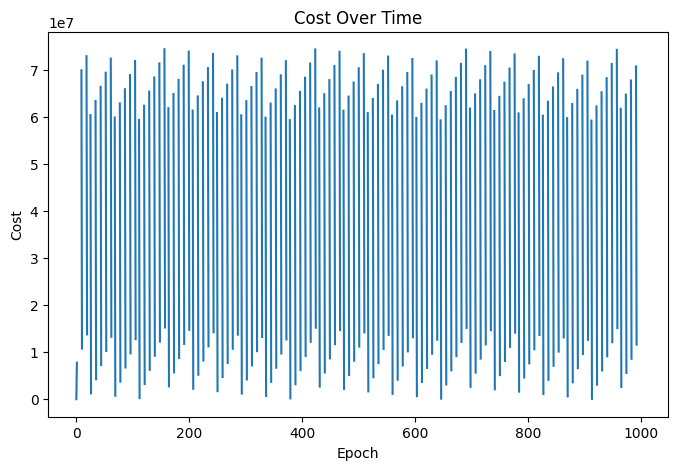

In [ ]:
model.plot_cost()

# Normalize & Try again

In [ ]:
model.normalize()
model.fit(epochs=1000, lr=0.01)

Epoch 0: Cost = 0.6931
Epoch 100: Cost = 0.4303
Epoch 200: Cost = 0.3194
Epoch 300: Cost = 0.2621
Epoch 400: Cost = 0.2279
Epoch 500: Cost = 0.2053
Epoch 600: Cost = 0.1893
Epoch 700: Cost = 0.1773
Epoch 800: Cost = 0.1681
Epoch 900: Cost = 0.1607


[np.float64(0.6931471805599454),
 np.float64(0.6890347142612936),
 np.float64(0.684963907403004),
 np.float64(0.680934332885536),
 np.float64(0.6769455656398309),
 np.float64(0.6729971827169704),
 np.float64(0.6690887633740087),
 np.float64(0.6652198891560293),
 np.float64(0.6613901439744848),
 np.float64(0.6575991141818749),
 np.float64(0.6538463886428215),
 np.float64(0.6501315588016103),
 np.float64(0.6464542187462554),
 np.float64(0.6428139652691587),
 np.float64(0.6392103979244321),
 np.float64(0.6356431190819508),
 np.float64(0.6321117339782089),
 np.float64(0.6286158507640498),
 np.float64(0.6251550805493458),
 np.float64(0.6217290374446975),
 np.float64(0.6183373386002308),
 np.float64(0.6149796042415631),
 np.float64(0.6116554577030159),
 np.float64(0.6083645254581481),
 np.float64(0.6051064371476853),
 np.float64(0.6018808256049183),
 np.float64(0.5986873268786492),
 np.float64(0.5955255802537555),
 np.float64(0.5923952282694492),
 np.float64(0.5892959167353015),
 np.float64(

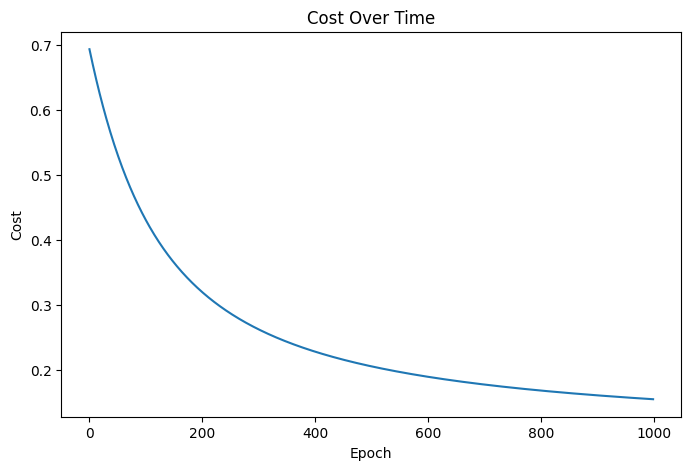

In [ ]:
model.plot_cost()

# **RESULTS**

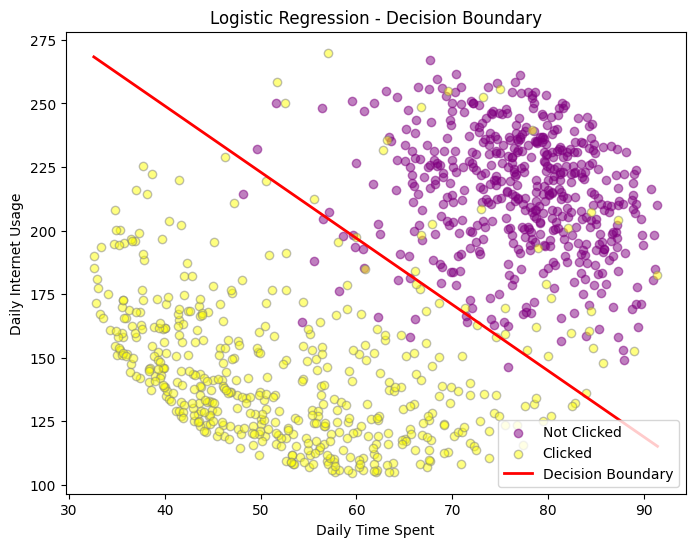

In [ ]:
model.plotresult_csv()

Bias (w0): 0.1107
Weight for Daily Time Spent: -1.1482
Weight for Age: 0.6249
Weight for Area Income: -0.6325
Weight for Daily Internet Usage: -1.2214
Weight for Male: -0.0805


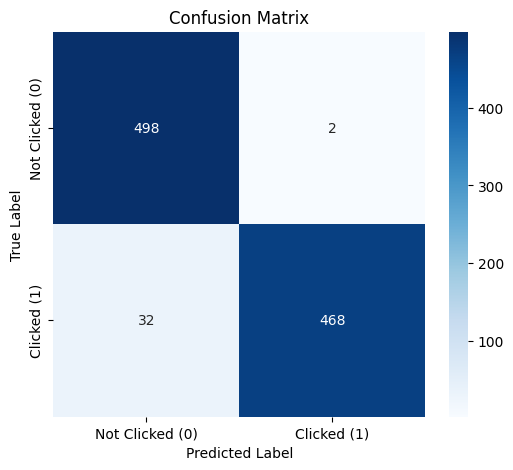

True Negatives (TN): 498
False Positives (FP): 2
False Negatives (FN): 32
True Positives (TP): 468
F1-Score: 0.9649
Accuracy: 96.60%


In [ ]:
predictions, probabilities = model.predict(model.X)

features = ['Daily Time Spent', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']
model.final_weights(feature_names=features)

metrics = model.metrics(model.y, predictions)
model.plot_matrix(model.y, predictions)
print(f"F1-Score: {metrics['F1-Score']:.4f}")
print(f"Accuracy: {metrics['Accuracy']:.2f}%")

# Dataset Manipulation

In [ ]:
model1 = LogisticRegresion()

### Default

X shape: (100, 2)
y shape: (100, 1)
Original X shape: (100, 2)
X with Bias shape: (100, 3)
Epoch 0: Cost = 0.6931
Epoch 100: Cost = 0.3973


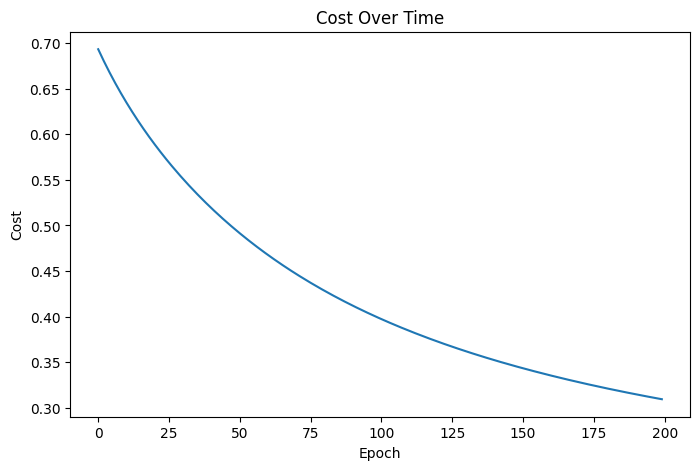

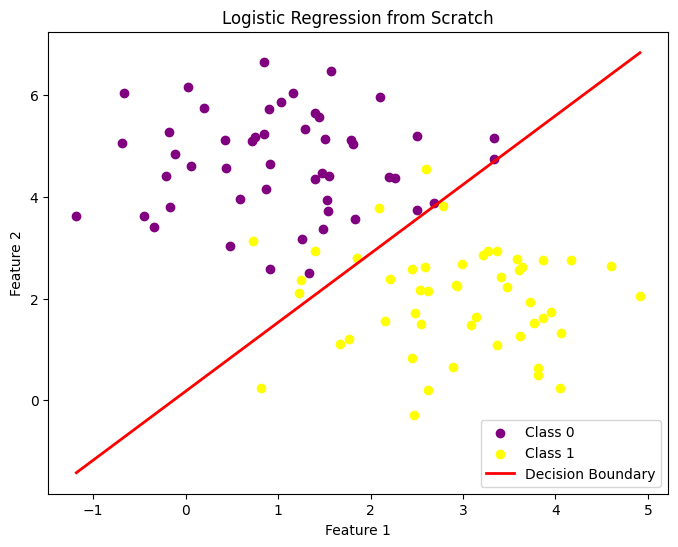

In [ ]:
model1.gendata(50)
model1.fit(epochs=200, lr=0.01)
model1.plot_cost()
model1.plot_result()

### High Varience

X shape: (100, 2)
y shape: (100, 1)
Original X shape: (100, 2)
X with Bias shape: (100, 3)
Epoch 0: Cost = 0.6931
Epoch 100: Cost = 0.5181


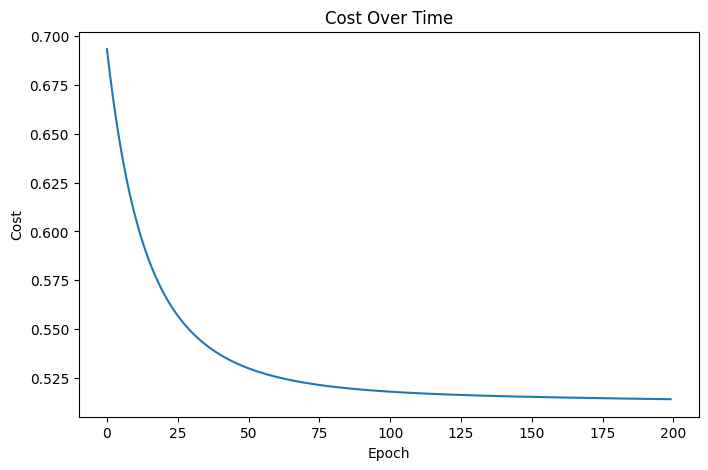

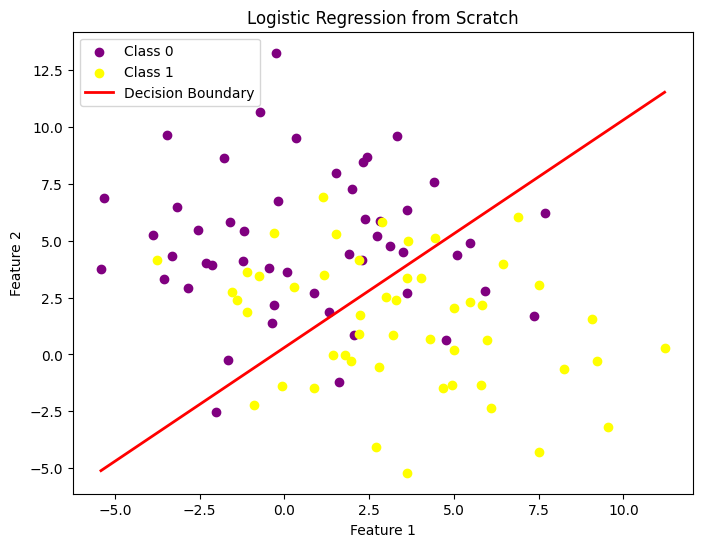

In [ ]:
model1.gendata(50, std=3.0)
model1.fit(epochs=200, lr=0.01)
model1.plot_cost()
model1.plot_result()

### Overlap

X shape: (100, 2)
y shape: (100, 1)
Original X shape: (100, 2)
X with Bias shape: (100, 3)
Epoch 0: Cost = 0.6931
Epoch 100: Cost = 0.6401


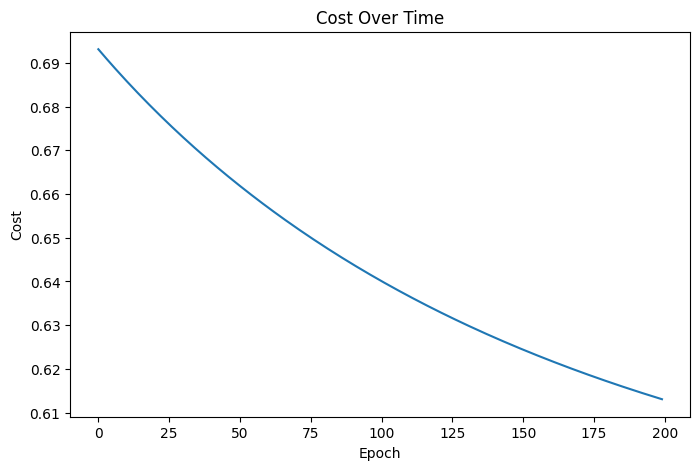

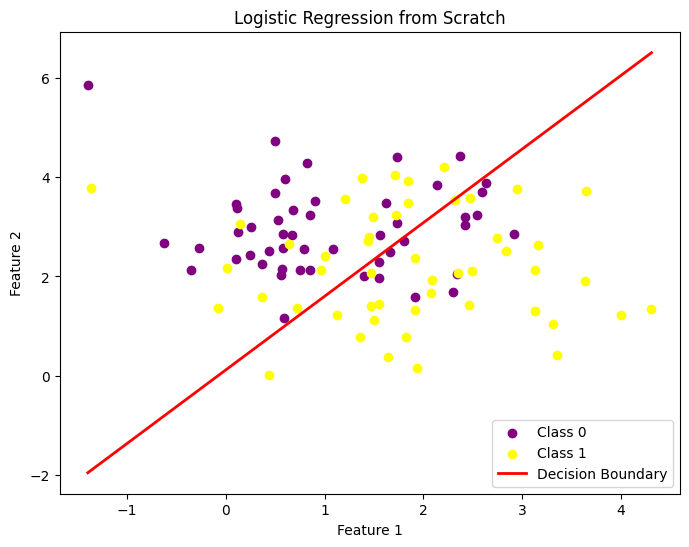

In [ ]:
model1.gendata(50, c0_x2=3, c1_x1=2)
model1.fit(epochs=200, lr=0.01)
model1.plot_cost()
model1.plot_result()

X shape: (10, 2)
y shape: (10, 1)
Original X shape: (10, 2)
X with Bias shape: (10, 3)
Epoch 0: Cost = 0.6931
Epoch 100: Cost = 0.2356


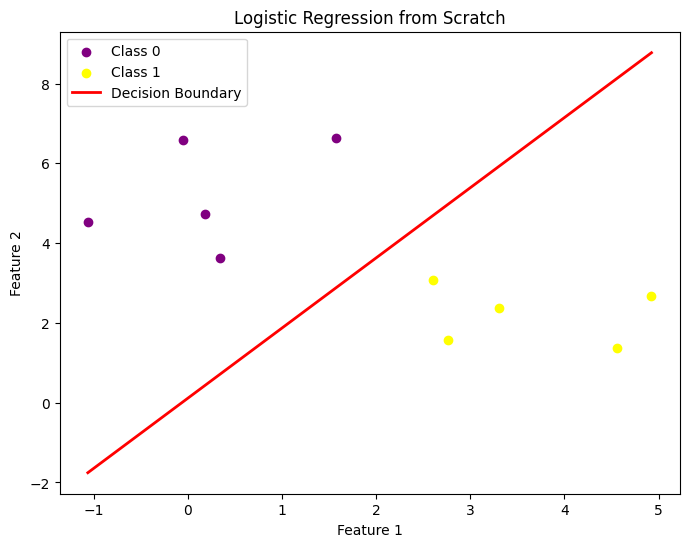

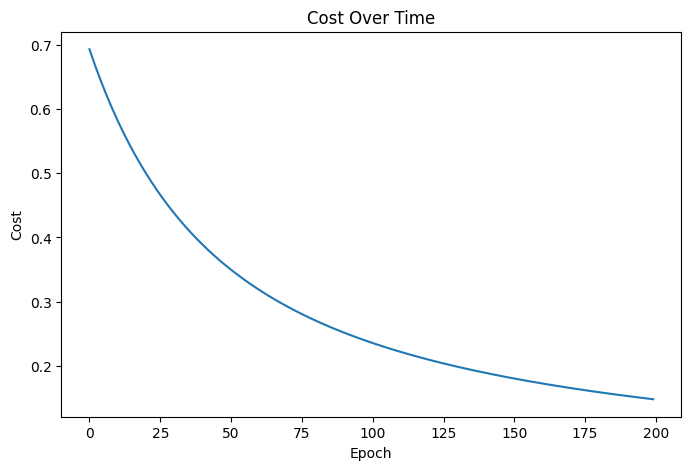

In [ ]:
model1.gendata(5)
model1.fit(epochs=200, lr=0.01)
model1.plot_result()
model1.plot_cost()

X shape: (1000, 2)
y shape: (1000, 1)
Original X shape: (1000, 2)
X with Bias shape: (1000, 3)
Epoch 0: Cost = 0.6931
Epoch 100: Cost = 0.3607


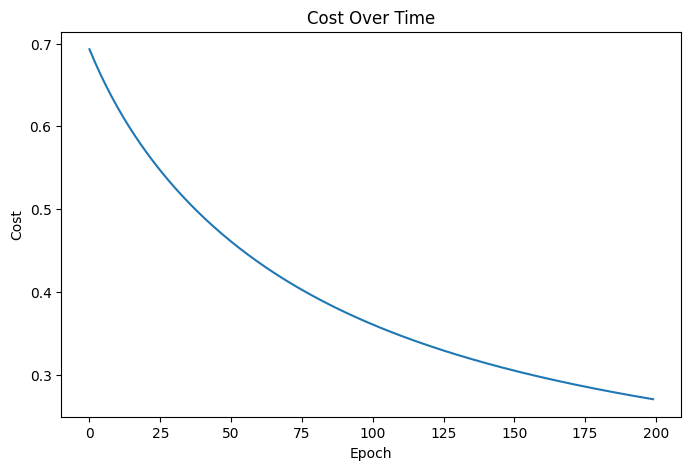

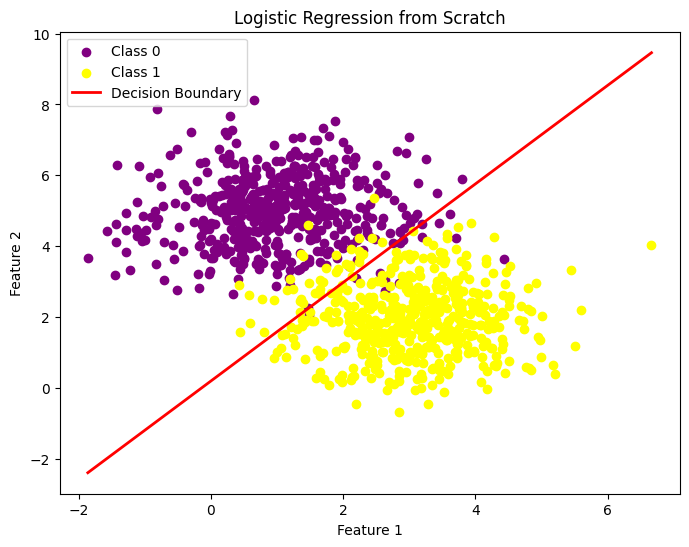

In [ ]:
model1.gendata(500)
model1.fit(epochs=200, lr=0.01)
model1.plot_cost()
model1.plot_result()